<a href="https://colab.research.google.com/github/yarolava/mn/blob/labwork/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна робота 2
# Наталіна Ярослава
#КС31
[source of the data (https://www.kaggle.com/datasets/abrambeyer/openintro-possum/data)

## 0. Import the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [61]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics

## 1. Load the data

In [ ]:
df = pd.read_csv("possum.csv")

df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


## 2. Preprocess the data

In [ ]:
df.columns

Index(['case', 'site', 'Pop', 'sex', 'age', 'hdlngth', 'skullw', 'totlngth',
       'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
case,0
site,0
Pop,0
sex,0
age,2
hdlngth,0
skullw,0
totlngth,0
taill,0
footlgth,1


In [ ]:
df.dropna(inplace=True)
print("Після видалення пропусків:", df.shape)

Після видалення пропусків: (101, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    object 
 3   sex       101 non-null    object 
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.8+ KB


In [ ]:
cat_val = df.select_dtypes(include=['object']).columns
num_val = df.select_dtypes(include=['int64', 'float64']).columns

print("Категоріальні змінні:\n", cat_val)
print("Числові змінні:\n", num_val)


Категоріальні змінні:
 Index(['Pop', 'sex'], dtype='object')
Числові змінні:
 Index(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='object')


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Унікальні значення в колонці '{column}': {unique_values}")


Унікальні значення в колонці 'case': [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  42  43  45  47  48  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75
  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93
  94  95  96  97  98  99 100 101 102 103 104]
Унікальні значення в колонці 'site': [1 2 3 4 5 6 7]
Унікальні значення в колонці 'Pop': ['Vic' 'other']
Унікальні значення в колонці 'sex': ['m' 'f']
Унікальні значення в колонці 'age': [8. 6. 2. 1. 9. 5. 3. 4. 7.]
Унікальні значення в колонці 'hdlngth': [ 94.1  92.5  94.   93.2  91.5  93.1  95.3  94.8  93.4  91.8  93.3  94.9
  95.1  95.4  92.9  91.6  94.7  93.5  94.4  95.9  96.3  95.8  96.   90.5
  93.8  92.8  92.1  94.3  91.4  90.6  89.3  92.4  84.7  91.   85.3  90.
  90.7  90.1  98.6  95.6  97.6  96.9 103.1  99.9  94.5 102.5  91.3  95.7
  92.

## 3. Do data visualization

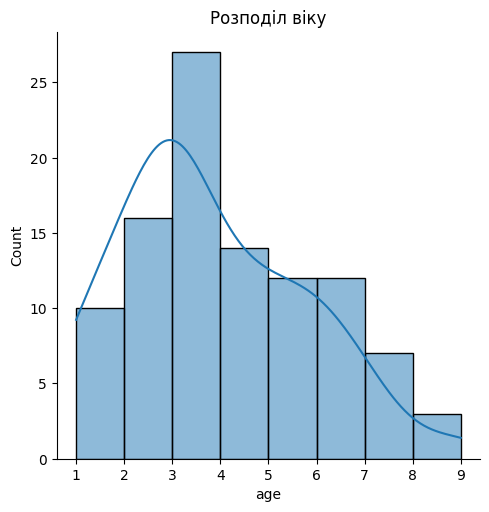

In [ ]:
sns.displot(df['age'], kde=True)
plt.title("Розподіл віку")
plt.show()

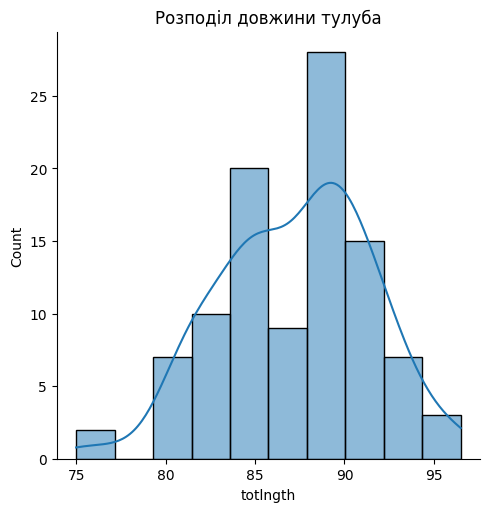

In [ ]:
sns.displot(df['totlngth'], kde=True)
plt.title("Розподіл довжини тулуба")
plt.show()

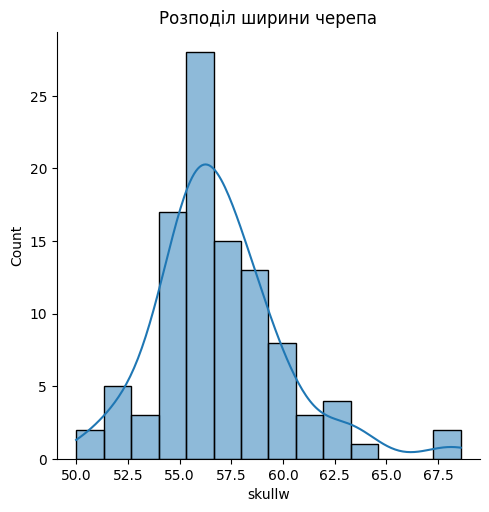

In [ ]:
sns.displot(df['skullw'], kde=True)
plt.title("Розподіл ширини черепа")
plt.show()

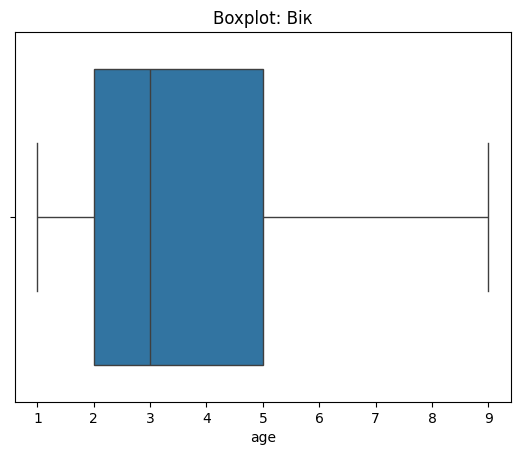

In [ ]:
sns.boxplot(x=df['age'])
plt.title("Boxplot: Вік")
plt.show()

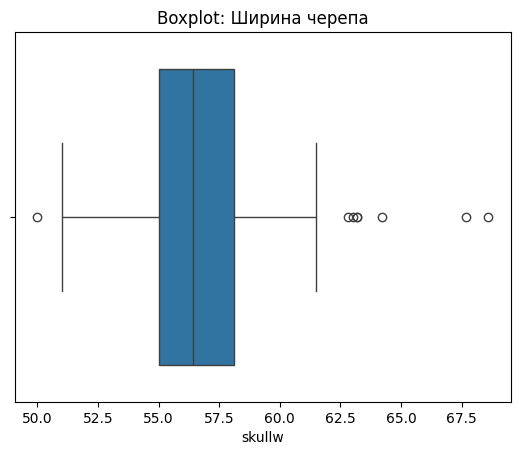

In [ ]:
sns.boxplot(x=df['skullw'])
plt.title("Boxplot: Ширина черепа")
plt.show()

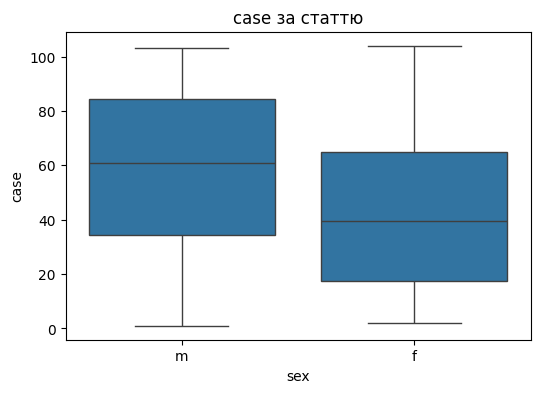

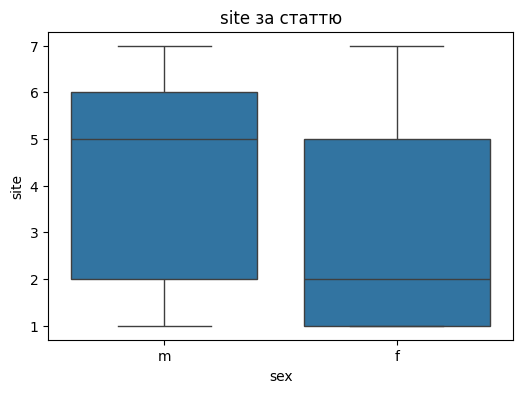

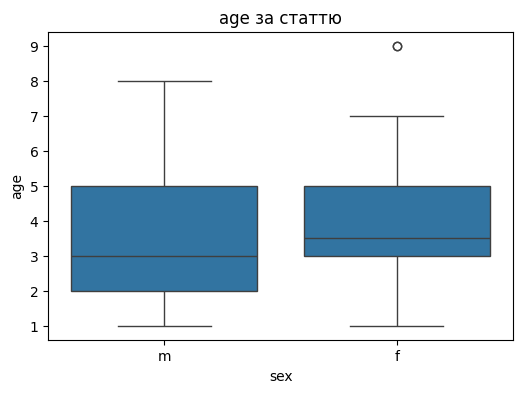

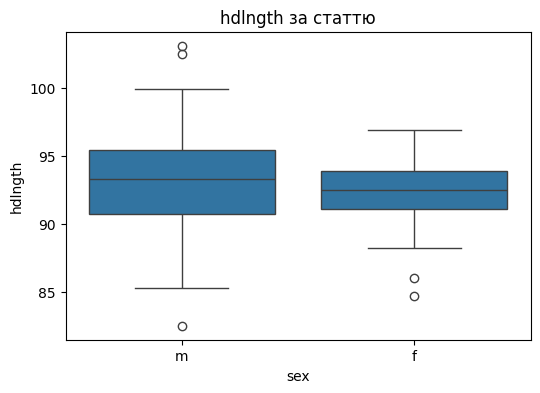

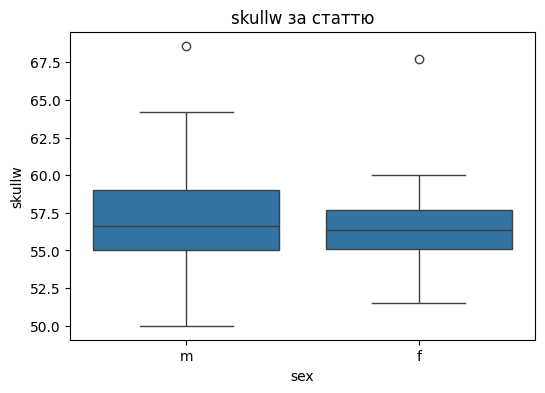

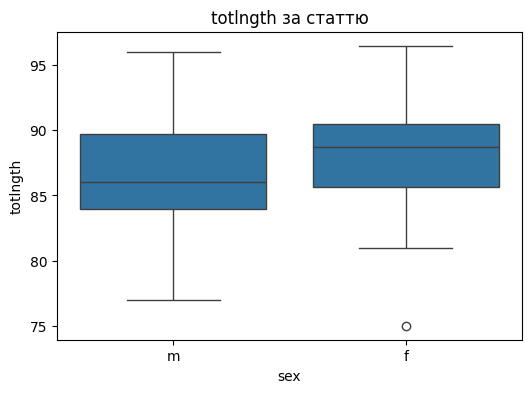

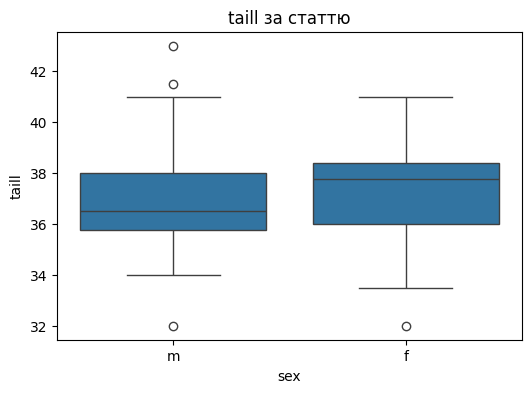

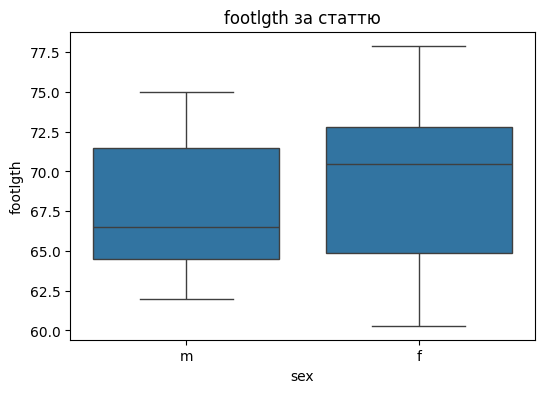

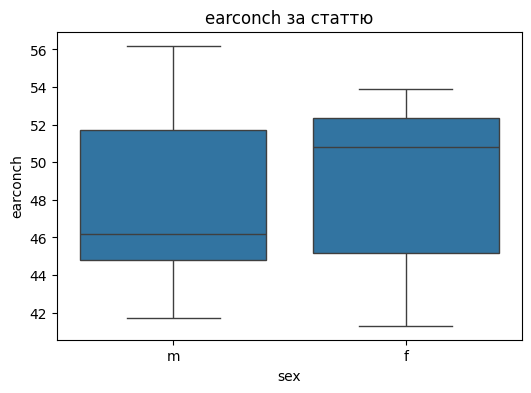

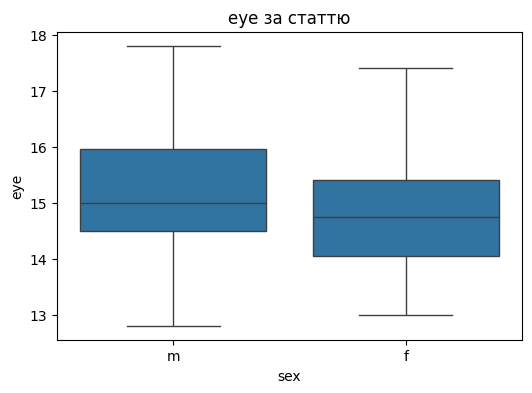

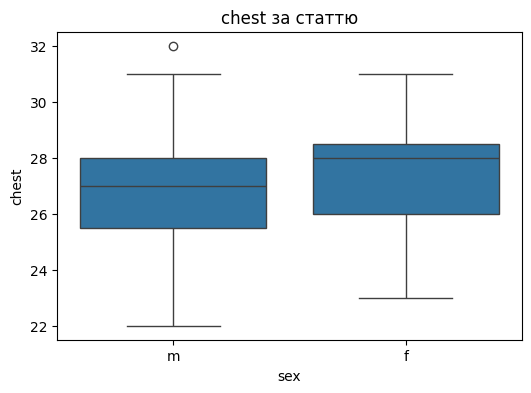

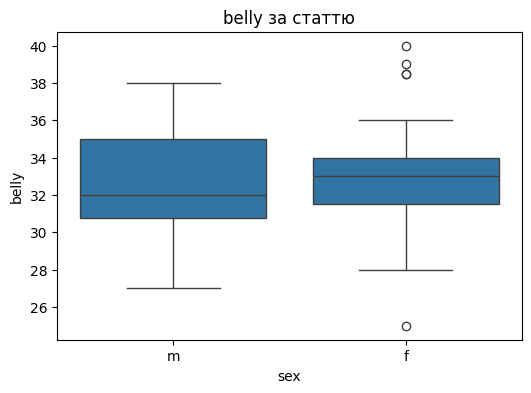

In [ ]:

for col in num_val:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='sex', y=col, data=df)
    plt.title(f"{col} за статтю")
    plt.show()


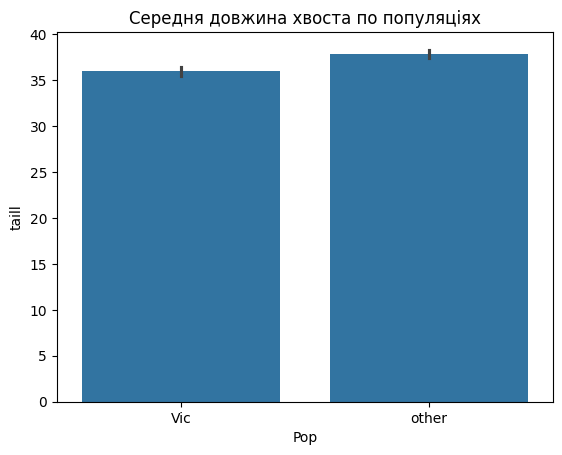

In [ ]:
sns.barplot(x='Pop', y='taill', data=df, estimator='mean')
plt.title("Середня довжина хвоста по популяціях")
plt.show()

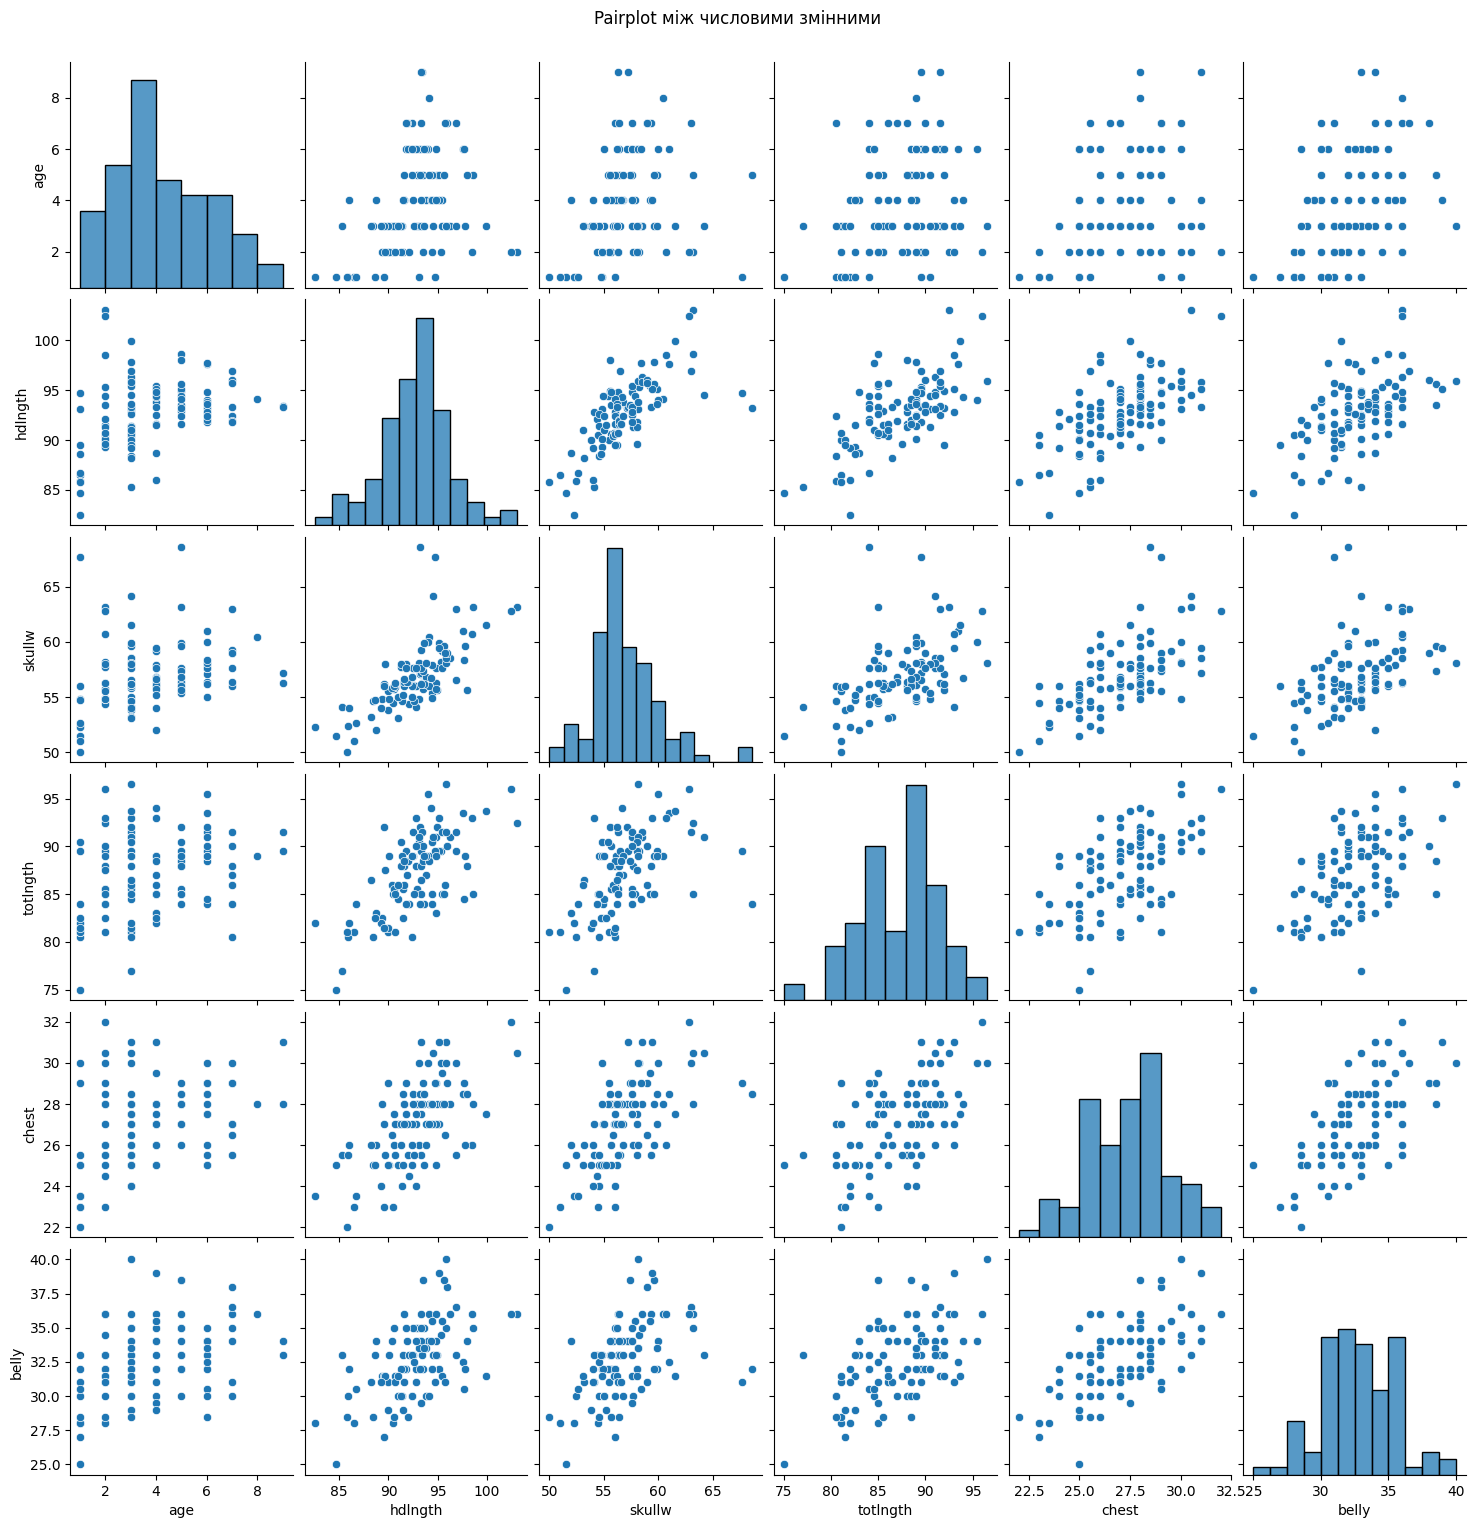

In [ ]:
sns.pairplot(df[['age', 'hdlngth', 'skullw', 'totlngth', 'chest', 'belly']])
plt.suptitle("Pairplot між числовими змінними", y=1.02)
plt.show()

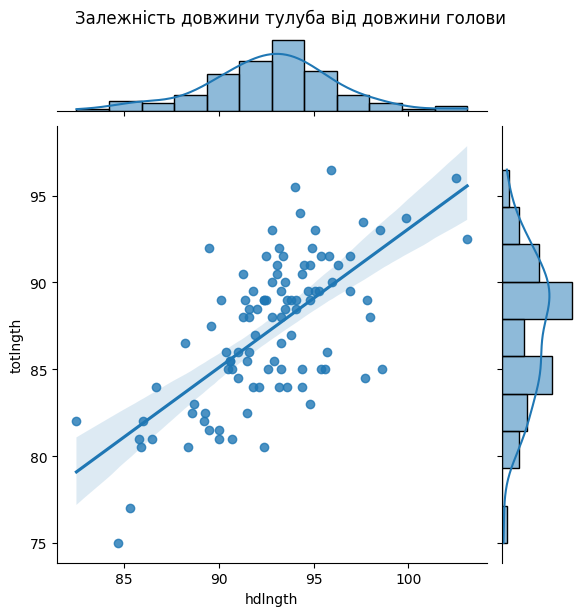

In [ ]:
sns.jointplot(x='hdlngth', y='totlngth', data=df, kind='reg')
plt.suptitle("Залежність довжини тулуба від довжини голови", y=1.02)
plt.show()


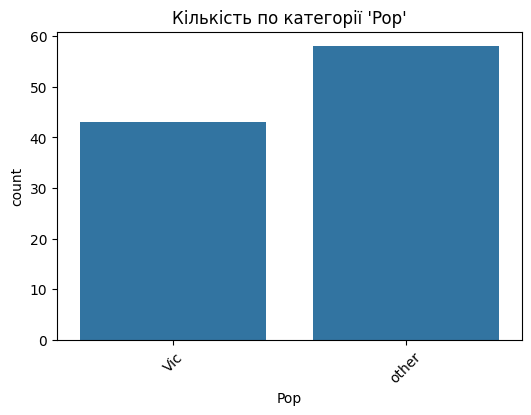

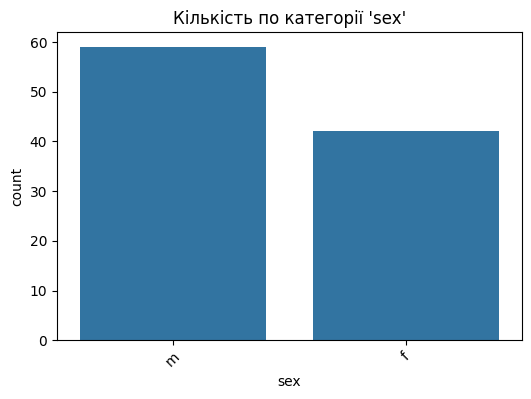

In [ ]:
for col in cat_val:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Кількість по категорії '{col}'")
    plt.xticks(rotation=45)
    plt.show()


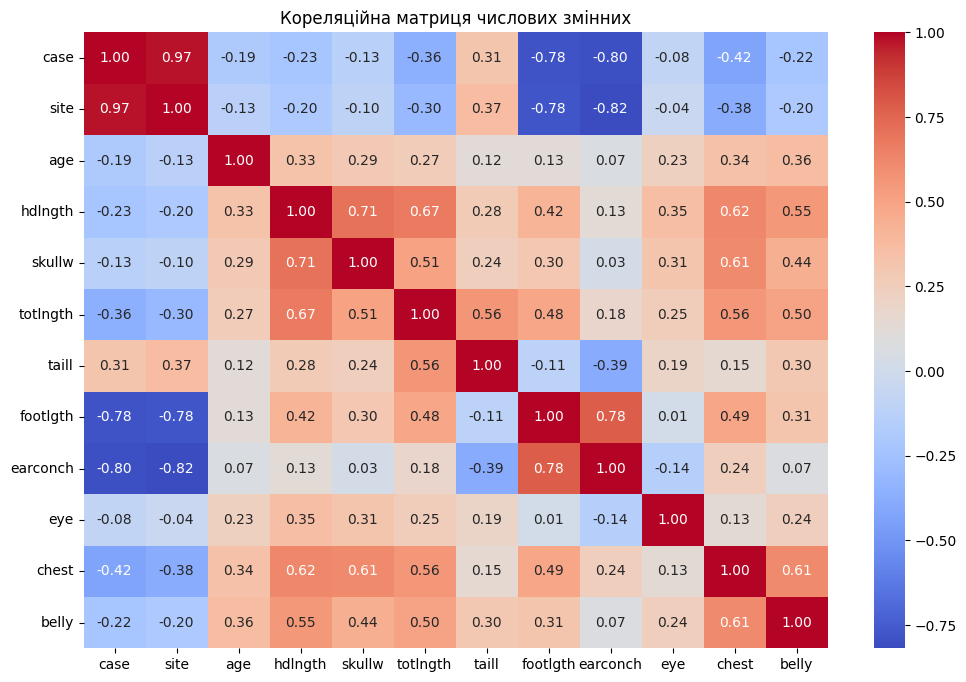

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_val].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Кореляційна матриця числових змінних")
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    object 
 3   sex       101 non-null    object 
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.8+ KB


## 4. Final data preps

In [42]:
y = df['totlngth']
X = df.drop(columns=['totlngth', 'case', 'Pop', 'sex', 'site'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8418)

mapper = {i: value for i, value in enumerate(X_train.columns)}

In [43]:
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    object 
 3   sex       101 non-null    object 
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.8+ KB


## 5.1 Test Linear Regression method

In [49]:

y = df['totlngth']

X = df.drop(columns=['totlngth', 'case'])

categorical_features = ['sex', 'Pop', 'site']

encoding = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_features)
], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8418)

pipe = Pipeline([
    ('encoding', encoding),
    ('lr', LinearRegression())
])

pipe.fit(X_train, y_train)

y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

print('🔹 Train R2 score:', metrics.r2_score(y_train, y_train_pred))
print('🔹 Train MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('🔹 Train RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))

# Test
print('🔹 Test R2 score:', metrics.r2_score(y_test, y_pred))
print('🔹 Test MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('🔹 Test RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))



🔹 Train R2 score: 0.8244166629207741
🔹 Train MAE: 1.3393432370659235
🔹 Train RMSE: 1.7525784435245073
🔹 Test R2 score: 0.6981643356196279
🔹 Test MAE: 1.6032875779744638
🔹 Test RMSE: 2.085262582980795


##
Bayesian Regression

In [53]:

pipe = Pipeline([
    ('encoding', encoding),
    ('bayes_ridge', BayesianRidge())
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

print('🔷 Модель: Bayesian Ridge Regression')
print('🔹 Train R2 score:', metrics.r2_score(y_train, y_train_pred))
print('🔹 Train MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('🔹 Train RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))

print('🔹 Test R2 score:', metrics.r2_score(y_test, y_pred))
print('🔹 Test MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('🔹 Test RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


🔷 Модель: Bayesian Ridge Regression
🔹 Train R2 score: 0.7835906752018844
🔹 Train MAE: 1.5351732939795575
🔹 Train RMSE: 1.9456906917656067
🔹 Test R2 score: 0.647087670722218
🔹 Test MAE: 1.6135380198015907
🔹 Test RMSE: 2.254804480139697


## Test Lasso Regression

In [55]:
pipe = Pipeline([
    ('encoding', encoding),
    ('model', Lasso(alpha=0.1))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("🔹 Lasso Regression")
print("Test R²:", metrics.r2_score(y_test, y_pred))
print("Test MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

🔹 Lasso Regression
Test R²: 0.6822780552598136
Test MAE: 1.5799079178722426
Test RMSE: 2.1394349175455916


## Decision Tree

In [56]:
pipe = Pipeline([
    ('encoding', encoding),
    ('model', DecisionTreeRegressor(random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("🔹 Decision Tree")
print("Test R²:", metrics.r2_score(y_test, y_pred))
print("Test MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


🔹 Decision Tree
Test R²: 0.23969631236442512
Test MAE: 2.65625
Test RMSE: 3.3095505737184316


## Random Forest

In [62]:
rfr = RandomForestRegressor()

param_grid = {
    "n_estimators": [10, 20, 30],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 4, 8],
    "bootstrap": [True, False]
}

grid_search = GridSearchCV(rfr, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)
print("Найкраща точність (R²):", grid_search.best_score_)


Найкращі параметри: {'bootstrap': False, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 20}
Найкраща точність (R²): 0.5206615565079267


In [80]:
x = df[numerical_columns + categorical_columns]

x_encoded = pd.get_dummies(x, columns=categorical_columns, drop_first=True)

x_encoded.head()


,age,hdlngth,skullw,taill,footlgth,earconch,eye,chest,belly,sex_m,Pop_other,site_2,site_3,site_4,site_5,site_6,site_7
0,8.0,94.1,60.4,36.0,74.5,54.5,15.2,28.0,36.0,True,False,False,False,False,False,False,False
1,6.0,92.5,57.6,36.5,72.5,51.2,16.0,28.5,33.0,False,False,False,False,False,False,False,False
2,6.0,94.0,60.0,39.0,75.4,51.9,15.5,30.0,34.0,False,False,False,False,False,False,False,False
3,6.0,93.2,57.1,38.0,76.1,52.2,15.2,28.0,34.0,False,False,False,False,False,False,False,False
4,2.0,91.5,56.3,36.0,71.0,53.2,15.1,28.5,33.0,False,False,False,False,False,False,False,False
